# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [2]:
df = pd.read_csv('../data/dayofweek.csv')

In [3]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [5]:
print("Without stratification:")
print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("Test class distribution:\n", y_test.value_counts(normalize=True))

Without stratification:
Train class distribution:
 3    0.232196
6    0.212908
1    0.164688
5    0.160237
2    0.092730
0    0.077893
4    0.059347
Name: dayofweek, dtype: float64
Test class distribution:
 3    0.245562
6    0.204142
5    0.162722
1    0.153846
0    0.091716
4    0.071006
2    0.071006
Name: dayofweek, dtype: float64


In [6]:
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y)

In [7]:
print("\nWith stratification:")
print("Train class distribution:\n", y_train_strat.value_counts(normalize=True))
print("Test class distribution:\n", y_test_strat.value_counts(normalize=True))


With stratification:
Train class distribution:
 3    0.234421
6    0.211424
1    0.162463
5    0.160979
2    0.088279
0    0.080861
4    0.061573
Name: dayofweek, dtype: float64
Test class distribution:
 3    0.236686
6    0.210059
1    0.162722
5    0.159763
2    0.088757
0    0.079882
4    0.062130
Name: dayofweek, dtype: float64


In [8]:
X_train, X_test, y_train, y_test = X_train_strat, X_test_strat, y_train_strat, y_test_strat

## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [9]:
def plot_top_features(importance, feature_names, top_n=10, title="Feature Importance"):
    imp_series = pd.Series(importance, index=feature_names).abs().sort_values(ascending=False)
    imp_series.head(top_n).sort_values().plot.barh(figsize=(8, 6))
    plt.title(f"{title} (top {top_n})")
    plt.xlabel("Coefficient / Importance")
    plt.show()

In [10]:
logreg = LogisticRegression(random_state=21, fit_intercept=False, max_iter=1000, solver='liblinear', multi_class='ovr')

In [11]:
logreg.fit(X_train, y_train)

LogisticRegression(fit_intercept=False, max_iter=1000, multi_class='ovr',
                   random_state=21, solver='liblinear')

In [12]:
y_pred_logreg = logreg.predict(X_test)

In [13]:
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"LogReg test accuracy: {acc_logreg:.4f}")

LogReg test accuracy: 0.6154


### b. SVM

In [14]:
svc_linear = SVC(kernel='linear', probability=True, random_state=21)
svc_linear.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=21)

In [15]:
y_pred_svc = svc_linear.predict(X_test)

In [16]:
acc_svc = accuracy_score(y_test, y_pred_svc)
print(f"SVC (linear) test accuracy: {acc_svc:.4f}")

SVC (linear) test accuracy: 0.7160


### c. Decision tree

In [17]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=21)

In [18]:
y_pred_tree = tree.predict(X_test)

In [19]:
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"DecisionTree test accuracy: {acc_tree:.4f}")

DecisionTree test accuracy: 0.5296


### d. Random forest

In [20]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=25, random_state=21)

In [21]:
y_pred_rf = rf.predict(X_test)

In [22]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"RandomForest test accuracy: {acc_rf:.4f}")

RandomForest test accuracy: 0.9290


No. Random Forest.

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [23]:
model_logreg = LogisticRegression(
    random_state=21,
    fit_intercept=False,
    max_iter=1000,
    solver='liblinear',
    multi_class='ovr'
)
scores_logreg = cross_val_score(model_logreg, X_train, y_train, cv=10, scoring='accuracy')
print("Logistic Regression:")
print(f"  mean accuracy = {scores_logreg.mean():.4f}")
print(f"  std deviation = {scores_logreg.std():.4f}")

Logistic Regression:
  mean accuracy = 0.5816
  std deviation = 0.0253


### b. SVM

In [24]:
model_svc = SVC(kernel='linear', random_state=21)
scores_svc = cross_val_score(model_svc, X_train, y_train, cv=10, scoring='accuracy')
print("SVC (linear):")
print(f"  mean accuracy = {scores_svc.mean():.4f}")
print(f"  std deviation = {scores_svc.std():.4f}")

SVC (linear):
  mean accuracy = 0.6587
  std deviation = 0.0436


### c. Decision tree

In [25]:
model_tree = DecisionTreeClassifier(max_depth=4, random_state=21)
scores_tree = cross_val_score(model_tree, X_train, y_train, cv=10, scoring='accuracy')
print("Decision Tree:")
print(f"  mean accuracy = {scores_tree.mean():.4f}")
print(f"  std deviation = {scores_tree.std():.4f}")

Decision Tree:
  mean accuracy = 0.5089
  std deviation = 0.0319


### d. Random forest

In [26]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
scores_rf = cross_val_score(model_rf, X_train, y_train, cv=10, scoring='accuracy')
print("Random Forest:")
print(f"  mean accuracy = {scores_rf.mean():.4f}")
print(f"  std deviation = {scores_rf.std():.4f}")

Random Forest:
  mean accuracy = 0.9177
  std deviation = 0.0216


## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [27]:
param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, 30, None]
}

model = RandomForestClassifier(random_state=21)

In [28]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=21), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, None],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [29]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'n_estimators': 200}
Best cross-validation score: 0.9028060030290513


In [30]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_best)
print(f"Test accuracy after tuning: {test_acc:.4f}")

Test accuracy after tuning: 0.9379


In [31]:
importance = best_model.feature_importances_

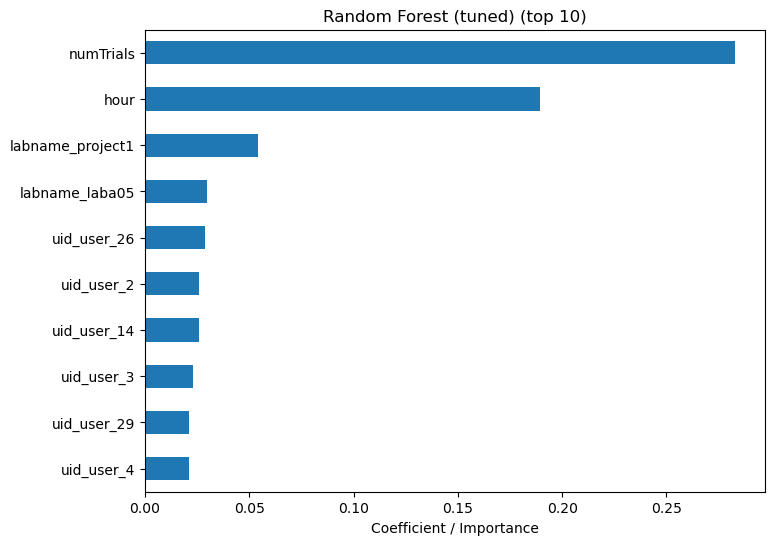

In [32]:
plot_top_features(importance, X.columns, top_n=10, title="Random Forest (tuned)")

In [33]:
joblib.dump(best_model, '../data/best_model.joblib')
print("Model saved as '../data/best_model.joblib'")

Model saved as '../data/best_model.joblib'


In [34]:
loaded_model = joblib.load('../data/best_model.joblib')
y_pred_loaded = loaded_model.predict(X_test)
acc_loaded = accuracy_score(y_test, y_pred_loaded)
print(f"Loaded model accuracy: {acc_loaded:.4f}")

Loaded model accuracy: 0.9379
